In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv("/content/online_education_dataset - online_education_dataset.csv")
df.head()

,id_student,gender,region,highest_education,studied_credits,imd_band,total_clicks,avg_score,engagement_level,performance_level,risk_level,pass_flag,dropout_flag,final_result
0,11391,M,East Anglian Region,HE Qualification,240,90-100%,934.0,82.0,Medium,High,Low Risk,1,0,Pass
1,28400,F,Scotland,HE Qualification,60,20-30%,1435.0,66.4,Medium,Medium,Low Risk,1,0,Pass
2,30268,F,North Western Region,A Level or Equivalent,60,30-40%,281.0,NaN,Low,NaN,Very High Risk,0,1,Withdrawn
3,31604,F,South East Region,A Level or Equivalent,60,50-60%,2158.0,76.0,High,High,Low Risk,1,0,Pass
4,32885,F,West Midlands Region,Lower Than A Level,60,50-60%,1034.0,54.4,Medium,Medium,Low Risk,1,0,Pass


In [4]:
df["final_result"].value_counts()

,count
final_result,
Pass,12361
Withdrawn,10156
Fail,7052
Distinction,3024


In [5]:
df.groupby("engagement_level")["pass_flag"].mean()

,pass_flag
engagement_level,
High,0.781354
Low,0.199194
Medium,0.571530


In [10]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         32593 non-null  int64  
 1   gender             32593 non-null  object 
 2   region             32593 non-null  object 
 3   highest_education  32593 non-null  object 
 4   studied_credits    32593 non-null  int64  
 5   imd_band           31482 non-null  object 
 6   total_clicks       29741 non-null  float64
 7   avg_score          26727 non-null  float64
 8   engagement_level   29741 non-null  object 
 9   performance_level  26695 non-null  object 
 10  risk_level         29741 non-null  object 
 11  pass_flag          32593 non-null  int64  
 12  dropout_flag       32593 non-null  int64  
 13  final_result       32593 non-null  object 
dtypes: float64(2), int64(4), object(8)
memory usage: 3.5+ MB


,id_student,studied_credits,total_clicks,avg_score,pass_flag,dropout_flag
count,3.259300e+04,32593.000000,29741.000000,26727.000000,32593.000000,32593.000000
mean,7.066877e+05,79.758691,1620.864665,72.828037,0.472034,0.311601
std,5.491673e+05,41.071900,2050.309532,15.564681,0.499225,0.463155
min,3.733000e+03,30.000000,1.000000,0.000000,0.000000,0.000000
25%,5.085730e+05,60.000000,324.000000,64.800000,0.000000,0.000000
50%,5.903100e+05,60.000000,903.000000,75.714286,0.000000,0.000000
75%,6.444530e+05,120.000000,2171.000000,84.055060,1.000000,1.000000
max,2.716795e+06,655.000000,28615.000000,100.000000,1.000000,1.000000


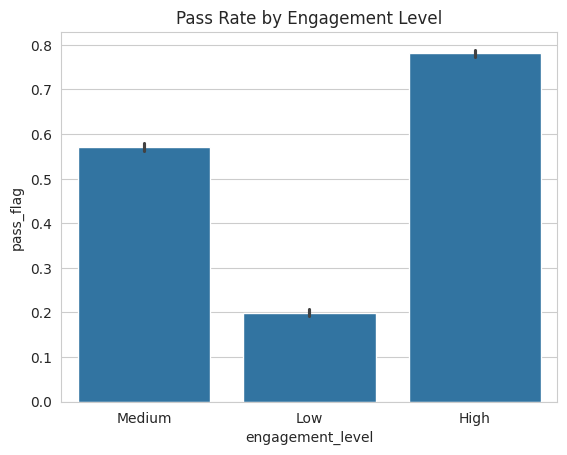

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(x="engagement_level",y="pass_flag",data=df)
plt.title("Pass Rate by Engagement Level")
sns.set_style("whitegrid")
plt.show()

In [16]:
df[["total_clicks","pass_flag"]].isnull().sum()

,0
total_clicks,2852
pass_flag,0


In [17]:
df["total_clicks"]=df["total_clicks"].fillna(0)
df["pass_flag"]=df["pass_flag"].fillna(0)

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
X=df[["total_clicks"]]
y=df[["pass_flag"]]
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
model=LogisticRegression(max_iter=1000)
model.fit(X_scaled,y)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(max_iter=1000)

In [24]:
print("Model coefficient:",model.coef_[0][0])

Model coefficient: 1.6158442072984183


<Axes: xlabel='engagement_level', ylabel='pass_flag'>

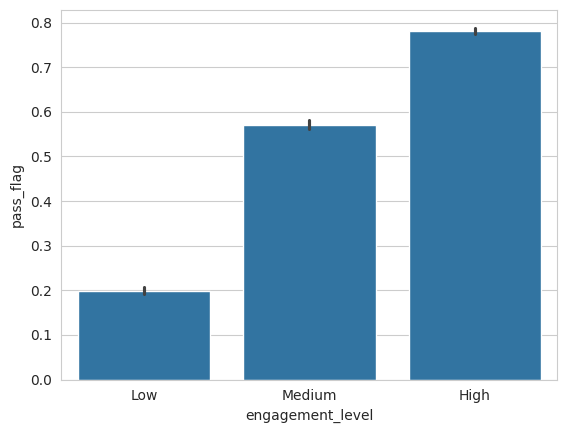

In [27]:
sns.barplot(
    x="engagement_level",
    y="pass_flag",
    data=df,
    order=["Low","Medium","High"]
)